## Generates the synthetic Data for Training the Model

First we need to do our imports and get our master csv file.

In [35]:
import pandas as pd
import nvdlib
import pprint
import json
import os
import ast
from dotenv import load_dotenv
import urllib.parse

# langchain imports
from langchain_ollama import ChatOllama
from langchain_core.prompts import ChatPromptTemplate
from langchain.tools import tool
from langchain_core.runnables import RunnableLambda
from pydantic import BaseModel, Field
from typing import Literal
from langchain.agents import create_agent

# for displaying graphs
from IPython.display import Image, display

# import playwright tool
import playwright_tool

Define the model. We also ask for JSON formatting as well, which uses Ollama's native JSON feature to force clean JSON output.

In [25]:
llm = ChatOllama(model="gpt-oss:20b", format="json")

In [3]:
master_df = pd.read_csv('normal_master.csv')
master_df.head()

,model_name,vendor,device_type,keyword_lookup
0,Xbox Series X,Microsoft,Gaming Console,Microsoft Xbox
1,Nintendo Switch,Nintendo,Gaming Console,Nintendo Switch
2,PlayStation 5,Sony,Gaming Console,Sony PlayStation
3,Plex Media Server,Plex,Media Server,Plex
4,Lockerstor (ADM),Asustor,NAS,Asustor


Now we connect to the NVD API.

In [4]:
load_dotenv()

nvd_api_key = os.getenv('NVD_API_KEY')

In [5]:
request = nvdlib.searchCVE(cveId='CVE-2021-26855', key=nvd_api_key, delay=2)
if request:
    pprint.pprint(request)

[{'id': 'CVE-2021-26855', 'sourceIdentifier': 'secure@microsoft.com', 'published': '2021-03-03T00:15:12.103', 'lastModified': '2025-10-30T19:55:58.670', 'vulnStatus': 'Analyzed', 'cveTags': [], 'descriptions': [{'lang': 'en', 'value': 'Microsoft Exchange Server Remote Code Execution Vulnerability'}, {'lang': 'es', 'value': 'Una Vulnerabilidad de Ejecución de código remota de Microsoft Exchange Server. Este ID de CVE es diferente de CVE-2021-26412, CVE-2021-26854, CVE-2021-26857, CVE-2021-26858, CVE-2021-27065, CVE-2021-27078'}], 'metrics': {'cvssMetricV31': [{'source': 'secure@microsoft.com', 'type': 'Secondary', 'cvssData': {'version': '3.1', 'vectorString': 'CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:H/A:N', 'baseScore': 9.1, 'baseSeverity': 'CRITICAL', 'attackVector': 'NETWORK', 'attackComplexity': 'LOW', 'privilegesRequired': 'NONE', 'userInteraction': 'NONE', 'scope': 'UNCHANGED', 'confidentialityImpact': 'HIGH', 'integrityImpact': 'HIGH', 'availabilityImpact': 'NONE'}, 'exploitabilit

In [6]:
device_name = "Ring Video Doorbell"

# Search for CVEs containing the device name
# limit=25 restricts the results to the top 25 matches
results = nvdlib.searchCVE(keywordSearch=device_name, limit=25, key=nvd_api_key, delay=2)

for entry in results:
    print(entry)

{'id': 'CVE-2015-4400', 'sourceIdentifier': 'cve@mitre.org', 'published': '2018-02-06T16:29:00.527', 'lastModified': '2024-11-21T02:31:00.143', 'vulnStatus': 'Modified', 'cveTags': [], 'descriptions': [{'lang': 'en', 'value': 'Ring (formerly DoorBot) video doorbells allow remote attackers to obtain sensitive information about the wireless network configuration by pressing the set up button and leveraging an API in the GainSpan Wi-Fi module.'}, {'lang': 'es', 'value': 'Los videoporteros Ring (anteriormente DoorBot) permiten que atacantes remotos obtengan información sensible sobre la configuración de red inalámbrica presionando el botón de configuración y utilizando una API en el módulo Wi-Fi GainSpan.'}], 'metrics': {'cvssMetricV30': [{'source': 'nvd@nist.gov', 'type': 'Primary', 'cvssData': {'version': '3.0', 'vectorString': 'CVSS:3.0/AV:P/AC:L/PR:N/UI:N/S:U/C:H/I:N/A:N', 'baseScore': 4.6, 'baseSeverity': 'MEDIUM', 'attackVector': 'PHYSICAL', 'attackComplexity': 'LOW', 'privilegesRequ

Now we will get all CVEs for the devices we are interested in and store them in a json file. Limit to top 25 CVEs returned by the API.

In [7]:
def extract_cve_context(nvd_data):
    """
    Parses a raw NVD API response to extract high-value context
    for LLM remediation analysis.
    """

    # 1. Extract ID and Description (English)
    cve_id = nvd_data["id"]
    
    # distinct descriptions often exist for different languages
    for entry in nvd_data["descriptions"]:
        if entry["lang"] == "en":
            description_text = entry["value"]
            break

    # this is a sanitization step
    if description_text:
        description_text = description_text.replace('\n', ' ').strip()   

    refs = nvd_data["references"]
    reference_urls = list({r["url"] for r in refs})

    # extract score data if available
    # will return the highest CVSS score available
    score_data = nvd_data["score"]
    print(score_data)

    # Build the structured context object
    return {
        "cve_id": cve_id,
        "description": description_text,
        "reference_links": reference_urls,
        "score_data": score_data
    }

In [8]:
# Helper function to serialize CVE object into a JSON object
def nvd_santizer(obj):
    if hasattr(obj, '__dict__'):
        obj["description"] = obj["description"].replace("\n", " ").strip()
        return obj.__dict__
    # Fallback: If it's something weird like a date object, convert to string
    print("FALLBACK TRIGGERED")
    return str(obj)

In [9]:
non_dup_keywords = master_df["keyword_lookup"].unique()

def create_cve_objects():
    # Open file in 'append' mode ('a') so we save progress as we go
    with open("discovered_cves.jsonl", "a", encoding="utf-8") as f:
        
        for keyword in non_dup_keywords:
            
            # Initialize the list for this specific keyword
            current_findings = []

            keyword_serialized = urllib.parse.quote_plus(keyword)

            # Run your search (Assuming you fixed the encoding/nvdlib parts)
            results = nvdlib.searchCVE(keywordSearch=keyword_serialized, limit=25, key=nvd_api_key, delay=1)
            
            for entry in results:
                # Extract your data (Assuming this function is now compatible)
                entry = ast.literal_eval(str(entry))
                print(entry)
                data = extract_cve_context(entry)
                current_findings.append(data)

            # 4. Save Strategy: Write ONLY this keyword's data to disk immediately
            # We wrap it in a mini-dict so we know which keyword these results belong to
            record_to_save = {keyword: current_findings}

            # print(record_to_save)
            
            # Dump to JSON string and add a newline (required for JSONL)
            f.write(json.dumps(record_to_save, default=nvd_santizer) + "\n")
            
            # Force the OS to write to the hard drive NOW (prevents data loss if script crashes)
            f.flush() 

# create_cve_objects()
# print("Scan complete. Data saved to discovered_cves.jsonl")

Validate JSONL completeness and syntactical correctness.

In [10]:
with open('discovered_cves.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        try:
            record = json.loads(line)
        except json.JSONDecodeError as e:
            print(f"Error decoding JSON: {e}")
            print(f"Offending line: {line}")

print("✅  JSONL file successfully read.")

✅  JSONL file successfully read.


Now we will define the SearXNG tool so the llm can use it if it needs to.

In [11]:
class SearXNGTool(BaseModel):
    """Tool to search the internet. Calling this tool will give you
    a markdown representation of 5 **full** websites."""
    query: str = Field(..., description="The search query to look up.")

In [12]:
@tool(args_schema=SearXNGTool)
async def searxng_search(query: str) -> str:
    """Use SearXNG to search the internet and return markdown content of top 5 websites."""
    search_results = await playwright_tool.search_and_parse_web(query=query)
    return search_results

Test the tool.

In [13]:
result = await searxng_search.ainvoke({"query": "What is the capital of France?"})
print(result)

Error querying SearXNG: All connection attempts failed


Add the tool in the format LangGraph will expect.

In [14]:
tools = [searxng_search]

## Begin Soultion Extraction
*WARNING* ⛔️

Although web scraping is a [legally protected act in the United States](https://blog.apify.com/is-web-scraping-legal), certain precations should be taken to ensure you are not banned from websites for scraping, or bogus legal cases are brought against you. TLDR; use a VPN which is sufficient for this level of scraping.

First, we'll define some logic to extract each CVE.

In [15]:
def extract_cve_context(device_json_obj):
    entries = []

    device = next(iter(device_json_obj))
    for cve in device_json_obj[device]:
        cve_id = cve.get("cve_id", "N/A")
        description = cve.get("description", "N/A")
        reference_links = cve.get("reference_links", [])
        score_data = cve.get("score_data", [])

        # make score data nice
        score_str = "Information not available."
        if score_data:
            score_str = f"""\
            Score Version: {score_data[0]}
            Score Value: {score_data[1]}
            Severity: {score_data[2]}
            """


        cve_dict = {
            "device": device,
            "cve_id": cve_id,
            "description": description,
            "reference_links": reference_links,
            "score_data": score_str
        }

        entries.append(cve_dict)
    return entries

Test the function.

In [16]:
with open('discovered_cves.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        device_entry = json.loads(line)
        print(extract_cve_context(device_entry))
        # break to just inspect the first entry
        break

[{'device': 'Microsoft Xbox', 'cve_id': 'CVE-2007-1220', 'description': 'The Hypervisor in Microsoft Xbox 360 kernel 4532 and 4548 does not properly verify the parameters passed to the syscall dispatcher, which allows attackers with physical access to bypass code-signing requirements and execute arbitrary code.', 'reference_links': ['http://www.securityfocus.com/bid/22745', 'http://securityreason.com/securityalert/2367', 'http://www.securityfocus.com/archive/1/461489/100/0/threaded'], 'score_data': '            Score Version: V2\n            Score Value: 6.2\n            Severity: MEDIUM\n            '}, {'device': 'Microsoft Xbox', 'cve_id': 'CVE-2007-1221', 'description': 'The Hypervisor in Microsoft Xbox 360 kernel 4532 and 4548 allows attackers with physical access to force execution of the hypervisor syscall with a certain register set, which bypasses intended code protection.', 'reference_links': ['http://www.securityfocus.com/bid/22745', 'http://securityreason.com/securityalert/

Make it a Runnable lambda.

In [38]:
cve_preprocessing = RunnableLambda(extract_cve_context)

with open('discovered_cves.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        device_entry = json.loads(line)
        print(cve_preprocessing.invoke(device_entry))
        # break to just inspect the first entry
        break

[{'device': 'Microsoft Xbox', 'cve_id': 'CVE-2007-1220', 'description': 'The Hypervisor in Microsoft Xbox 360 kernel 4532 and 4548 does not properly verify the parameters passed to the syscall dispatcher, which allows attackers with physical access to bypass code-signing requirements and execute arbitrary code.', 'reference_links': ['http://www.securityfocus.com/bid/22745', 'http://securityreason.com/securityalert/2367', 'http://www.securityfocus.com/archive/1/461489/100/0/threaded'], 'score_data': '            Score Version: V2\n            Score Value: 6.2\n            Severity: MEDIUM\n            '}, {'device': 'Microsoft Xbox', 'cve_id': 'CVE-2007-1221', 'description': 'The Hypervisor in Microsoft Xbox 360 kernel 4532 and 4548 allows attackers with physical access to force execution of the hypervisor syscall with a certain register set, which bypasses intended code protection.', 'reference_links': ['http://www.securityfocus.com/bid/22745', 'http://securityreason.com/securityalert/

### Implement Load Site Logic
This handles direct loading from reference URLs.

In [41]:
async def direct_load_sites(device_obj: dict) -> dict:
    """Recieve a CVE dict, load all reference links, and return a structured dict including site content."""
    device_cves = []

    for cve_dict in device_obj:
        # hold site Markdown results
        results = []

        urls = cve_dict.get("reference_links", [])
        for url in urls:
            content = await playwright_tool.direct_load(url)
            results.append(content)

        template_dict = {
                "device": cve_dict.get("device", "N/A"),
                "cve_id": cve_dict.get("cve_id", "N/A"),
                "description": cve_dict.get("description", "N/A"),
                "all_references": "\n\n".join(results),
                "score_data": cve_dict.get("score_data", "")
            }
        
        device_cves.append(template_dict)

    return device_cves

direct_load = RunnableLambda(direct_load_sites)

In [43]:
mock_concatenated_score = """\
            Score Version: V2
            Score Value: 7.3
            Severity: HIGH
            """

test_data = {
    "device": "Fake Device",
    "cve_id": "CVE-XXXX-YYYY",
    "description": "This is a fake CVE for testing purposes.",
    "reference_links": ["https://www.google.com", "https://www.cnn.com"],
    "score_data": mock_concatenated_score
    }

# wrap in a list since direct_load expects a list of CVE dicts
result = await direct_load.ainvoke([test_data])
print(result)

[{'device': 'Fake Device', 'cve_id': 'CVE-XXXX-YYYY', 'description': 'This is a fake CVE for testing purposes.', 'all_references': '<begin_page>\n<source url=https://www.google.com />\n*Gmail*\n*Images*\n*Sign in*\nGoogle\n*AdvertisingBusiness SolutionsAbout Google*\n*© 2025 - Privacy - Terms*\n\n\n</end_page>\n\n\n<begin_page>\n<source url=https://www.cnn.com />\n*Thank You!*\nYour effort and contribution in providing this feedback is much appreciated.\n*Close*\n*Ad Feedback*\nTrending Football coach jailed\n*Times New Roman*\nUnderwater ‘storms’\n*$30 billion sustainable city*\n*Thailand-Cambodia conflict*\n*CNN Underscored Gifts for friends*\nTakeaways: Powell says the Fed has delivered enough rate cuts for now\nSherrone Moore jailed hours after being fired as University of Michigan’s head football coach\nUkraine presents response to US peace plan as Trump says European leaders want a meeting\n## US seizes oil tanker off Venezuelan coast, Trump says\n*Show all*\nAttorney General Bon

Test it operating as a chain.

In [54]:
test_chain = cve_preprocessing | direct_load

batch_list = []

samples = 0
with open('discovered_cves.jsonl', 'r', encoding='utf-8') as f:
    # for line in f:
    #     device_entry = json.loads(line)
    #     print(await test_chain.ainvoke(device_entry))
    #     # break to just inspect the first entry
    #     break
    for line in f:
        device_entry = json.loads(line)
        batch_list.append(device_entry)
        if samples >= 2:
            break
        samples += 1

print(await test_chain.abatch(batch_list))

No features in text.


[[{'device': 'Microsoft Xbox', 'cve_id': 'CVE-2007-1220', 'description': 'The Hypervisor in Microsoft Xbox 360 kernel 4532 and 4548 does not properly verify the parameters passed to the syscall dispatcher, which allows attackers with physical access to bypass code-signing requirements and execute arbitrary code.', 'all_references': 'No content found at http://www.securityfocus.com/bid/22745.\n\n<begin_page>\n<source url=http://securityreason.com/securityalert/2367 />\nHome Page\nHome\nBugtraq\nFull List\nOnly Bugs\nOnly Tricks\nOnly Exploits\nOnly Dorks\nOnly CVE\nOnly CWE\nFake Notes\nRanking\nCVEMAP\nFull List\nShow Vendors\nShow Products\nCWE Dictionary\nCheck CVE Id\nCheck CWE Id\nSearch\nBugtraq\nCVEMAP\nBy author\nCVE Id\nCWE Id\nBy vendors\nBy products\nRSS\nBugtraq\nCVEMAP\nCVE Products\nBugs\nExploits\nDorks\nMore\ncIFrex\nFacebook\nTwitter\nDonate\nAbout\nSubmit\nXbox 360 Hypervisor Privilege Escalation Vulnerability 2007-03-08 / 2007-03-09 Credit: Anonymous Hacker Risk: High

## Set up Langchain 🦜
Start defining model and prompt template.

Test the connection to the model.

In [26]:
llm.invoke("What is the capital of France?").content

'{"answer":"Paris"}'

Awesome! Now let's make the prompt template.

In [27]:
system_prompt = """\
You are an expert Cybersecurity Researcher and Remediation Analyst.
Your goal is to use the provided CVE and context to identify **precise, and actionable technical resolution steps**.

### RESEARCH STRATEGY:
You have access to a 'searxng_search' tool. The tool will give you 5 markdown rendered webpages per query. You must use it rigorously to validate your findings.
1. **Source Hierarchy:** Prioritize official vendor advisories (e.g., Microsoft, Cisco, Netgear, Sony, etc.) and NVD data over forums or third-party blogs.
2. **Search Depth:** Do not rely on a single search. You must verify the specific **patch version numbers**, **KB article IDs**, or **configuration changes** required.
3. **Iterative Verification:** If a search result is generic (e.g., "Update your software"), perform a follow-up search to find *which version* contains the fix. \
Ensure the fix also includes the instructions on *how* to update the software (e.g. "Open settings, go to updates, tap or click update")

### RESOLUTION CRITERIA:
- **RESOLVED:** If a fix exists, provide the exact version number to upgrade to, or the specific configuration command to run. Detail is crucial, but ensure it is *actionable* (e.g., "Upgrade to v1.2.3" is better than "Apply the latest patch").
- **UNRESOLVED:** If you confirm no fix exists (e.g., End-of-Life or 0-day with no patch), state clearly that it is unresolved and cite the vendor's statement if available.

### IMPORTANT:
Use 'searxng_search' multiple times with varied queries (e.g., "CVE-2023-XXXX vendor advisory", "CVE-2023-XXXX patch notes", "CVE-2023-XXXX workaround") before synthesizing your final answer.
"""

Now we can make the react agent that will power the research of vulnerabilities.

In [33]:
research_agent = create_agent(
    llm,
    tools=tools,
    system_prompt=system_prompt,
)

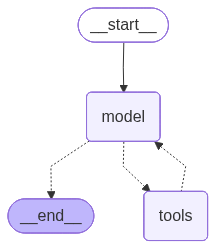

In [36]:
display(Image(research_agent.get_graph().draw_mermaid_png()))

Now we make the prompt the model will respond to. Few shot prompting is used here to clarify exactly what we want to the model.

In [ ]:
# TODO: Set up dynamic prompt generation function incorporating few-shot examples
# and formatting based on the dynamic number of CVEs being processed.

Before proceding test the model to make sure it can effectively use it's tool. *Note: JSON output will vary as we have not yet defined a schema for the model to follow*.

In [ ]:
# test on the new React Exploit
react_concatenated_score = """\
            Score Version: V3
            Score Value: 10.0
            Severity: CRITICAL
            """

react_exploit = {
    "device": "React Server",
    "cve_id": "CVE-2025-55182",
    "description": "A pre-authentication remote code execution vulnerability exists in React Server Components versions 19.0.0, 19.1.0, 19.1.1, and 19.2.0 including the following packages: react-server-dom-parcel, react-server-dom-turbopack, and react-server-dom-webpack. The vulnerable code unsafely deserializes payloads from HTTP requests to Server Function endpoints.",
    # test with context and without context
    "reference_links": ["http://www.openwall.com/lists/oss-security/2025/12/03/4", 
                        "https://aws.amazon.com/blogs/security/china-nexus-cyber-threat-groups-rapidly-exploit-react2shell-vulnerability-cve-2025-55182/",
                        "https://news.ycombinator.com/item?id=46136026",
                        "https://react.dev/blog/2025/12/03/critical-security-vulnerability-in-react-server-components",
                        "https://www.cisa.gov/known-exploited-vulnerabilities-catalog?field_cve=CVE-2025-55182",
                        "https://www.facebook.com/security/advisories/cve-2025-55182",
                        ],
    # "reference_links": [],
    "score_data": react_concatenated_score
    }

test_chain = direct_load | research_agent
result = await test_chain.ainvoke(react_exploit)
print(result)

{'messages': [AIMessage(content='{"error":"No CVE was provided. Please specify the CVE identifier (e.g., CVE-2023-12345) and any related context you have so that I can research the exact fix or workaround for you."}', additional_kwargs={}, response_metadata={'model': 'gpt-oss:20b', 'created_at': '2025-12-11T04:24:48.679155Z', 'done': True, 'done_reason': 'stop', 'total_duration': 3902940584, 'load_duration': 1374083667, 'prompt_eval_count': 633, 'prompt_eval_duration': 13135750, 'eval_count': 49, 'eval_duration': 565176458, 'logprobs': None, 'model_name': 'gpt-oss:20b', 'model_provider': 'ollama'}, id='lc_run--019b0ba7-7de6-70e2-aaa1-362bd1b9dad5-0', usage_metadata={'input_tokens': 633, 'output_tokens': 49, 'total_tokens': 682})]}
